In [64]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [4]:
customers = pd.read_csv(r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\customer_master.csv")
procurement_orders = pd.read_csv(r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\procurement_orders.csv")
products = pd.read_csv(r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\product_master.csv")
sales_orders = pd.read_csv(r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\sales_orders.csv")
suppliers = pd.read_csv(r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\supplier_master.csv")

In [5]:
customers.head()

,Customer_ID,Customer_Name,Industry,Market_Segment,Country,City,Latitude,Longitude
0,CUST00001,Avery Williams,Education,B2B,Germany,Copenhagen,87.2981,-51.1869
1,CUST00002,Morgan Jones,Healthcare,B2C,Denmark,Tokyo,48.9622,53.2143
2,CUST00003,Sam Johnson,Telecom,B2C,Spain,Sao Paulo,-85.1099,-135.7486
3,CUST00004,Morgan Rodriguez,Finance,B2C,Germany,Mumbai,-78.2632,139.9173
4,CUST00005,Skyler Wilson,IT,B2C,UK,London,-6.4924,1.1102


In [6]:
procurement_orders.head()

,PO_ID,Supplier_ID,Raw_Material_ID,Order_Date,Order_Quantity,Unit_Cost,Delivery_Date_Planned,Delivery_Date_Actual,Total_Cost
0,PO000001,SUP00059,PROD00116,2024-03-19,10,42.345023,2024-04-02,2024-04-03,423.450228
1,PO000002,SUP00085,PROD00153,2021-06-24,5,74.805687,2021-07-04,2021-07-07,374.028437
2,PO000003,SUP00097,PROD00170,2023-08-16,11,76.080119,2023-09-02,2023-09-06,836.881310
3,PO000004,SUP00023,PROD00016,2023-05-01,7,64.157844,2023-05-17,2023-05-14,449.104907
4,PO000005,SUP00048,PROD00041,2022-10-31,10,53.179121,2022-11-24,2022-11-24,531.791209


In [7]:
products.head()

,Product_ID,SKU,Product_Name,Category,Subcategory,Unit,Unit_Cost,Standard_Price,Launch_Date,Discontinuation_Date
0,PROD00001,XAJI0Y6DPB,Gamma Apex Gadget,Food,A,pcs,131.74,198.31,2022-11-18,NaN
1,PROD00002,HSAHXTHV3A,Ultra Omega Device,Beauty,E,pcs,141.88,339.56,2023-04-13,NaN
2,PROD00003,3ZMF8MDD4V,Alpha Fusion Gadget,Sport,D,pcs,160.18,187.85,2022-03-16,NaN
3,PROD00004,30T9NT3W5U,Apex Apex Item,Food,D,pcs,178.55,224.00,2022-01-04,NaN
4,PROD00005,ZBIKCIDKWN,Fusion Prime Widget,Home,D,pcs,70.91,246.55,2023-10-08,NaN


In [8]:
sales_orders.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Status,Order_Quantity,Unit_Price,Discount,Shipping_Mode,Shipping_Carrier,Shipping_Date_Scheduled,Shipping_Date_Actual,Delivery_Status,Late_Delivery_Risk_Flag,VAT_Rate,COGS,Unit_Price_Effective,Order_Total,VAT_Amount,Profit_Per_Order
0,ORD0000001,CUST00481,PROD00135,2023-06-16,Completed,8,200.54,0.12,Standard,CarrierA,2023-06-21,2023-06-21,On Time,0,0.19,1510.96,176.4752,1411.8016,268.242304,-99.1584
1,ORD0000002,CUST00111,PROD00147,2023-09-23,Pending,3,220.96,0.18,Same Day,CarrierB,2023-09-26,2023-09-26,On Time,0,0.20,371.61,181.1872,543.5616,108.712320,171.9516
2,ORD0000003,CUST00104,PROD00172,2022-12-17,Cancelled,2,15.87,0.09,Economy,CarrierD,2022-12-18,2022-12-20,Late,1,0.20,16.46,14.4417,28.8834,5.776680,12.4234
3,ORD0000004,CUST00316,PROD00063,2023-10-11,Pending,7,191.91,0.06,Express,CarrierC,2023-10-15,2023-10-19,Late,1,0.00,1166.20,180.3954,1262.7678,0.000000,96.5678
4,ORD0000005,CUST00171,PROD00065,2022-10-04,Completed,6,192.00,0.19,Same Day,CarrierB,2022-10-05,2022-10-05,On Time,0,0.20,358.68,155.5200,933.1200,186.624000,574.4400


In [9]:
suppliers.head()

,Supplier_ID,Supplier_Name,Country,Region,On_Time_Delivery_Rate,Certification_Level,Preferred_Supplier_Flag
0,SUP00001,Beta Gamma Corp,USA,West,0.75,NaN,0
1,SUP00002,Eco Gamma GmbH,China,South,0.80,ISO 9001,0
2,SUP00003,Ultra Ultra GmbH,India,Central,0.62,ISO 14001,1
3,SUP00004,Gamma Nova LLC,USA,North,0.66,ISO 9001,0
4,SUP00005,Ultra Gamma LLC,Canada,North,0.89,ISO 9001,1


## Order Quantity for each product

In [10]:
order_qty_by_product = sales_orders[['Product_ID','Order_Quantity']].groupby(['Product_ID']).sum()

In [11]:
order_qty_by_product.sort_values(by=['Order_Quantity'],ascending=False).head()

,Order_Quantity
Product_ID,
PROD00143,729
PROD00087,638
PROD00048,628
PROD00016,613
PROD00112,612


In [65]:
sales_orders['Order_Date'] = pd.to_datetime(sales_orders['Order_Date'])

In [67]:
sales_orders.head(2)

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Status,Order_Quantity,Unit_Price,Discount,Shipping_Mode,Shipping_Carrier,Shipping_Date_Scheduled,Shipping_Date_Actual,Delivery_Status,Late_Delivery_Risk_Flag,VAT_Rate,COGS,Unit_Price_Effective,Order_Total,VAT_Amount,Profit_Per_Order
0,ORD0000001,CUST00481,PROD00135,2023-06-16,Completed,8,200.54,0.12,Standard,CarrierA,2023-06-21,2023-06-21,On Time,0,0.19,1510.96,176.4752,1411.8016,268.242304,-99.1584
1,ORD0000002,CUST00111,PROD00147,2023-09-23,Pending,3,220.96,0.18,Same Day,CarrierB,2023-09-26,2023-09-26,On Time,0,0.20,371.61,181.1872,543.5616,108.712320,171.9516


In [85]:
sales_by_date = sales_orders[['Order_Date','Order_Quantity']].groupby(by='Order_Date').sum()

In [86]:
sales_by_date.sort_values(by='Order_Quantity',ascending=False).head()

,Order_Quantity
Order_Date,
2023-06-25,197
2024-01-04,181
2022-07-31,177
2023-03-18,174
2023-01-06,174


In [87]:
sales_by_date.reset_index(inplace=True)

In [88]:
sales_by_date['Weekday'] = sales_by_date['Order_Date'].dt.day_name()
sales_by_date['Month'] = sales_by_date['Order_Date'].dt.month_name()

In [90]:
sales_by_date.head()

,Order_Date,Order_Quantity,Weekday,Month
0,2022-01-01,55,Saturday,January
1,2022-01-02,81,Sunday,January
2,2022-01-03,110,Monday,January
3,2022-01-04,87,Tuesday,January
4,2022-01-05,101,Wednesday,January


In [93]:
order_qty_by_weekday = sales_by_date[['Weekday','Order_Quantity']].groupby(by='Weekday').sum()
order_qty_by_weekday

,Order_Quantity
Weekday,
Friday,15259
Monday,14393
Saturday,13630
Sunday,14445
Thursday,14370
Tuesday,13919
Wednesday,14196


In [96]:
order_qty_by_weekday.sort_values(by='Order_Quantity',ascending=False)

,Order_Quantity
Weekday,
Friday,15259
Sunday,14445
Monday,14393
Thursday,14370
Wednesday,14196
Tuesday,13919
Saturday,13630


## Most of the Customers are placing Orders on Friday

In [94]:
order_qty_by_month = sales_by_date[['Month','Order_Quantity']].groupby(by='Month').sum()
order_qty_by_month

,Order_Quantity
Month,
April,8859
August,9581
December,5943
February,8286
January,9748
July,9617
June,9503
March,9244
May,9360


## Compared to all months orders placed on October, November, December are very less

In [95]:
order_qty_by_month.sort_values(by='Order_Quantity',ascending=False)

,Order_Quantity
Month,
January,9748
July,9617
August,9581
June,9503
May,9360
March,9244
April,8859
September,8401
February,8286


## [Nova Fusion Gadget] is the Highest Selling Product with TotalOrderQuantity of 729

In [12]:
products[products['Product_ID']=='PROD00143']

,Product_ID,SKU,Product_Name,Category,Subcategory,Unit,Unit_Cost,Standard_Price,Launch_Date,Discontinuation_Date
142,PROD00143,SS9TOQW9JA,Nova Fusion Gadget,Beauty,A,pcs,151.71,264.41,2023-09-19,NaN


In [13]:
order_qty = (order_qty_by_product.merge(products,on=products['Product_ID'],how='right')[['Product_ID','SKU','Product_Name','Category','Subcategory','Order_Quantity']])

In [14]:
order_qty.sort_values(by=['Order_Quantity'],ascending=False).tail()

,Product_ID,SKU,Product_Name,Category,Subcategory,Order_Quantity
197,PROD00198,J70E3P15AH,Pioneer Nova Widget,Apparel,D,401
158,PROD00159,P6BEFFLZM7,Gamma Apex Widget,Industrial,D,396
121,PROD00122,ES6M033IFH,Omega Prime Gadget,Electronics,C,373
7,PROD00008,H75LXO6QJI,Eco Ultra Item,Food,C,354
19,PROD00020,PKI7P5TB94,Alpha Omega Item,Beauty,C,345


In [15]:
qty_by_cat = order_qty[['Category','Order_Quantity']].groupby(by=['Category']).sum()

In [16]:
qty_by_cat.reset_index(inplace=True)

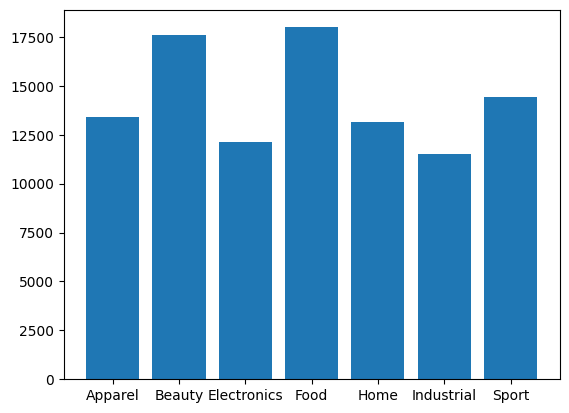

In [17]:
plt.bar(qty_by_cat['Category'],qty_by_cat['Order_Quantity'])
plt.show()

## Beauty and Food categories are the most selling categories

In [18]:
qty_by_pd = order_qty[['Product_Name','Order_Quantity']].groupby(by=['Product_Name']).sum()

In [19]:
top_5_prod = qty_by_pd.sort_values(by=['Order_Quantity'],ascending=False).head()

In [20]:
top_5_prod.reset_index(inplace=True)

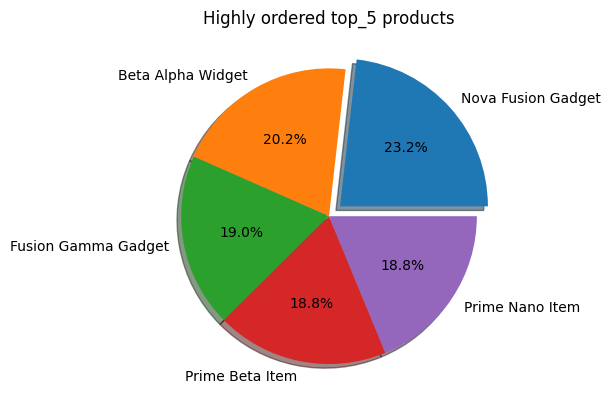

In [21]:
plt.pie(top_5_prod['Order_Quantity'],labels=top_5_prod['Product_Name'],explode=[0.1,0,0,0,0],shadow=True,autopct='%1.1f%%')
plt.title('Highly ordered top_5 products')
plt.show()

In [22]:
sales_orders.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Status,Order_Quantity,Unit_Price,Discount,Shipping_Mode,Shipping_Carrier,Shipping_Date_Scheduled,Shipping_Date_Actual,Delivery_Status,Late_Delivery_Risk_Flag,VAT_Rate,COGS,Unit_Price_Effective,Order_Total,VAT_Amount,Profit_Per_Order
0,ORD0000001,CUST00481,PROD00135,2023-06-16,Completed,8,200.54,0.12,Standard,CarrierA,2023-06-21,2023-06-21,On Time,0,0.19,1510.96,176.4752,1411.8016,268.242304,-99.1584
1,ORD0000002,CUST00111,PROD00147,2023-09-23,Pending,3,220.96,0.18,Same Day,CarrierB,2023-09-26,2023-09-26,On Time,0,0.20,371.61,181.1872,543.5616,108.712320,171.9516
2,ORD0000003,CUST00104,PROD00172,2022-12-17,Cancelled,2,15.87,0.09,Economy,CarrierD,2022-12-18,2022-12-20,Late,1,0.20,16.46,14.4417,28.8834,5.776680,12.4234
3,ORD0000004,CUST00316,PROD00063,2023-10-11,Pending,7,191.91,0.06,Express,CarrierC,2023-10-15,2023-10-19,Late,1,0.00,1166.20,180.3954,1262.7678,0.000000,96.5678
4,ORD0000005,CUST00171,PROD00065,2022-10-04,Completed,6,192.00,0.19,Same Day,CarrierB,2022-10-05,2022-10-05,On Time,0,0.20,358.68,155.5200,933.1200,186.624000,574.4400


In [23]:
ord_qty_sp_mode = sales_orders[['Shipping_Mode','Order_Quantity']].groupby(by='Shipping_Mode').sum()

In [24]:
ord_qty_sp_mode.reset_index(inplace=True)

In [25]:
ord_qty_sp_mode

,Shipping_Mode,Order_Quantity
0,Economy,24752
1,Express,25022
2,Same Day,25339
3,Standard,25099


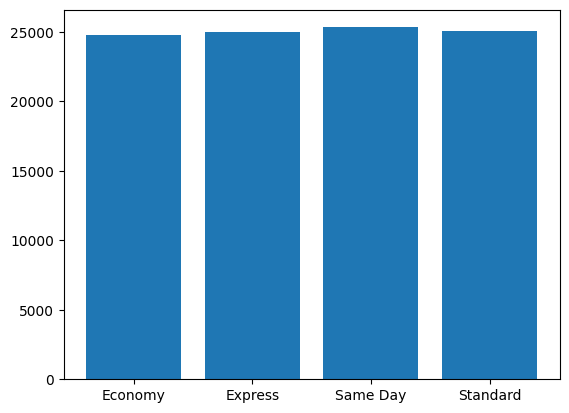

In [26]:
plt.bar(ord_qty_sp_mode['Shipping_Mode'],ord_qty_sp_mode['Order_Quantity'])
plt.show()

In [27]:
sales_agg = sales_orders.groupby('Product_ID')['Order_Total'].sum().reset_index()

In [28]:
sales_agg.head()

,Product_ID,Order_Total
0,PROD00001,73675.1790
1,PROD00002,78336.1624
2,PROD00003,79480.0834
3,PROD00004,115542.6959
4,PROD00005,51084.5835


In [29]:
revenue = order_qty.merge(sales_agg,on='Product_ID',how='left')

In [30]:
revenue.head()

,Product_ID,SKU,Product_Name,Category,Subcategory,Order_Quantity,Order_Total
0,PROD00001,XAJI0Y6DPB,Gamma Apex Gadget,Food,A,481,73675.1790
1,PROD00002,HSAHXTHV3A,Ultra Omega Device,Beauty,E,435,78336.1624
2,PROD00003,3ZMF8MDD4V,Alpha Fusion Gadget,Sport,D,520,79480.0834
3,PROD00004,30T9NT3W5U,Apex Apex Item,Food,D,518,115542.6959
4,PROD00005,ZBIKCIDKWN,Fusion Prime Widget,Home,D,450,51084.5835


In [31]:
revenue['Order_Total'] = revenue['Order_Total'].astype(int)

In [32]:
revenue_by_cat = revenue[['Category','Order_Total']].groupby(by='Category').sum()

In [33]:
revenue_by_cat.reset_index(inplace=True)

In [34]:
revenue_by_cat

,Category,Order_Total
0,Apparel,1798472
1,Beauty,2981914
2,Electronics,1649700
3,Food,3041529
4,Home,2011020
5,Industrial,1834499
6,Sport,2196002


## Total Revenue by each category

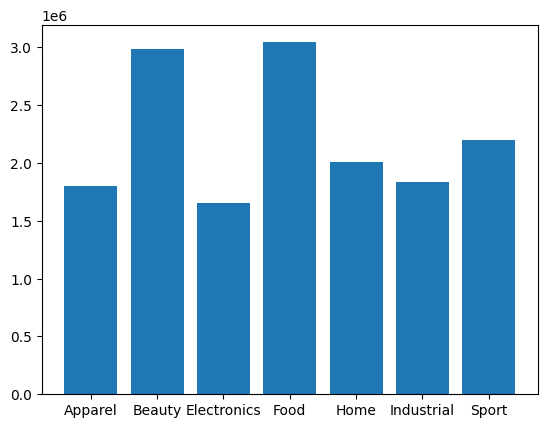

In [35]:
plt.bar(revenue_by_cat['Category'],revenue_by_cat['Order_Total'])
plt.show()

<p>Food and Beauty products generated more revenue compared to other category of products</p>

In [36]:
suppliers.head(2)

,Supplier_ID,Supplier_Name,Country,Region,On_Time_Delivery_Rate,Certification_Level,Preferred_Supplier_Flag
0,SUP00001,Beta Gamma Corp,USA,West,0.75,NaN,0
1,SUP00002,Eco Gamma GmbH,China,South,0.80,ISO 9001,0


In [37]:
procurement_orders.head(2)

,PO_ID,Supplier_ID,Raw_Material_ID,Order_Date,Order_Quantity,Unit_Cost,Delivery_Date_Planned,Delivery_Date_Actual,Total_Cost
0,PO000001,SUP00059,PROD00116,2024-03-19,10,42.345023,2024-04-02,2024-04-03,423.450228
1,PO000002,SUP00085,PROD00153,2021-06-24,5,74.805687,2021-07-04,2021-07-07,374.028437


In [38]:
sup_ord_cost = procurement_orders.merge(suppliers,on='Supplier_ID',how='left')[['Supplier_ID','Supplier_Name','Country','Raw_Material_ID','Order_Quantity','Total_Cost','On_Time_Delivery_Rate','Preferred_Supplier_Flag']]

In [39]:
sup_ord_cost.head()

,Supplier_ID,Supplier_Name,Country,Raw_Material_ID,Order_Quantity,Total_Cost,On_Time_Delivery_Rate,Preferred_Supplier_Flag
0,SUP00059,Vertex Beta GmbH,India,PROD00116,10,423.450228,0.62,0
1,SUP00085,Beta Delta LLC,Germany,PROD00153,5,374.028437,0.72,1
2,SUP00097,Beta Pioneer Inc,USA,PROD00170,11,836.881310,0.81,1
3,SUP00023,Nova Beta Corp,Brazil,PROD00016,7,449.104907,0.62,1
4,SUP00048,Delta Gamma Corp,Denmark,PROD00041,10,531.791209,0.94,1


In [40]:
sup_ord_cost['Preferred_Supplier_Flag'].value_counts()

Preferred_Supplier_Flag
0    1046
1     954
Name: count, dtype: int64

## There are 96 unique suppliers to order from

In [41]:
len(suppliers['Supplier_Name'].unique())

96

In [42]:
order_qty_by_sup = sup_ord_cost[['Supplier_Name','Order_Quantity']].groupby(by='Supplier_Name').sum()

In [43]:
order_qty_by_sup.reset_index(inplace=True)

In [44]:
top_3_sup = order_qty_by_sup.sort_values(by='Order_Quantity',ascending=False).head(3)

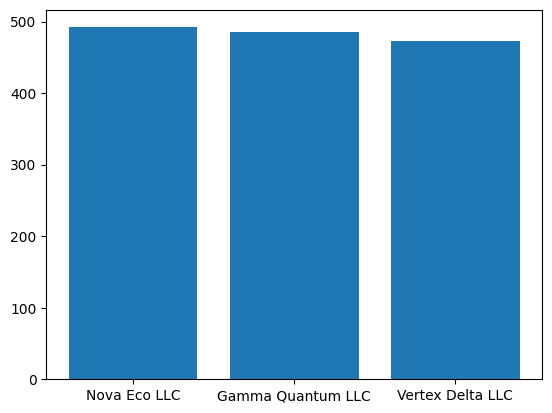

In [45]:
plt.bar(top_3_sup['Supplier_Name'],top_3_sup['Order_Quantity'])
plt.show()

In [55]:
len(suppliers[suppliers['On_Time_Delivery_Rate']>0.8])

52

### There are 52 Suppliers with OnTimeDeliveryRate greater than 80%

In [97]:
procurement_orders.head()

,PO_ID,Supplier_ID,Raw_Material_ID,Order_Date,Order_Quantity,Unit_Cost,Delivery_Date_Planned,Delivery_Date_Actual,Total_Cost
0,PO000001,SUP00059,PROD00116,2024-03-19,10,42.345023,2024-04-02,2024-04-03,423.450228
1,PO000002,SUP00085,PROD00153,2021-06-24,5,74.805687,2021-07-04,2021-07-07,374.028437
2,PO000003,SUP00097,PROD00170,2023-08-16,11,76.080119,2023-09-02,2023-09-06,836.881310
3,PO000004,SUP00023,PROD00016,2023-05-01,7,64.157844,2023-05-17,2023-05-14,449.104907
4,PO000005,SUP00048,PROD00041,2022-10-31,10,53.179121,2022-11-24,2022-11-24,531.791209


In [99]:
procurement_orders[['Order_Date','Delivery_Date_Planned','Delivery_Date_Actual']] = procurement_orders[['Order_Date','Delivery_Date_Planned','Delivery_Date_Actual']].apply(pd.to_datetime)

In [101]:
pro = procurement_orders

In [102]:
pro['Planned_vs_Actual_delivery'] = abs(pro['Delivery_Date_Planned'] - pro['Delivery_Date_Actual'])

In [103]:
pro.head()

,PO_ID,Supplier_ID,Raw_Material_ID,Order_Date,Order_Quantity,Unit_Cost,Delivery_Date_Planned,Delivery_Date_Actual,Total_Cost,Planned_vs_Actual_delivery
0,PO000001,SUP00059,PROD00116,2024-03-19,10,42.345023,2024-04-02,2024-04-03,423.450228,1 days
1,PO000002,SUP00085,PROD00153,2021-06-24,5,74.805687,2021-07-04,2021-07-07,374.028437,3 days
2,PO000003,SUP00097,PROD00170,2023-08-16,11,76.080119,2023-09-02,2023-09-06,836.881310,4 days
3,PO000004,SUP00023,PROD00016,2023-05-01,7,64.157844,2023-05-17,2023-05-14,449.104907,3 days
4,PO000005,SUP00048,PROD00041,2022-10-31,10,53.179121,2022-11-24,2022-11-24,531.791209,0 days


In [108]:
supplier_delay_time = pro[['Supplier_ID','Planned_vs_Actual_delivery']].sort_values(by='Planned_vs_Actual_delivery',ascending=False)

In [114]:
supplier_delay_time['Planned_vs_Actual_delivery'].value_counts()

Planned_vs_Actual_delivery
1 days    405
2 days    403
3 days    373
4 days    213
5 days    212
6 days    199
0 days    195
Name: count, dtype: int64

In [119]:
supplier_delay_time[supplier_delay_time['Planned_vs_Actual_delivery'].dt.days > 3].head()

,Supplier_ID,Planned_vs_Actual_delivery
1348,SUP00010,6 days
1296,SUP00044,6 days
1802,SUP00020,6 days
1796,SUP00079,6 days
948,SUP00073,6 days


In [120]:
len(supplier_delay_time[supplier_delay_time['Planned_vs_Actual_delivery'].dt.days > 3])

624

## 624 time's Suppliers sent the orders that were 3 or more days late than actual expected date

In [121]:
pro['time_btw_ord_n_del'] = abs(pro['Order_Date'] - pro['Delivery_Date_Actual'])

In [122]:
pro.head()

,PO_ID,Supplier_ID,Raw_Material_ID,Order_Date,Order_Quantity,Unit_Cost,Delivery_Date_Planned,Delivery_Date_Actual,Total_Cost,Planned_vs_Actual_delivery,time_btw_ord_n_del
0,PO000001,SUP00059,PROD00116,2024-03-19,10,42.345023,2024-04-02,2024-04-03,423.450228,1 days,15 days
1,PO000002,SUP00085,PROD00153,2021-06-24,5,74.805687,2021-07-04,2021-07-07,374.028437,3 days,13 days
2,PO000003,SUP00097,PROD00170,2023-08-16,11,76.080119,2023-09-02,2023-09-06,836.881310,4 days,21 days
3,PO000004,SUP00023,PROD00016,2023-05-01,7,64.157844,2023-05-17,2023-05-14,449.104907,3 days,13 days
4,PO000005,SUP00048,PROD00041,2022-10-31,10,53.179121,2022-11-24,2022-11-24,531.791209,0 days,24 days


In [128]:
pro['time_btw_ord_n_del'].mean()

Timedelta('18 days 16:18:28.800000')

## the average time between the Order placing and revceiving the order is 18days